In [1]:
# ===== 02_ask_spread — CELL 1 : telechargement H1 ASK =====
import time
from datetime import datetime
import pandas as pd
import dukascopy_python
from dukascopy_python import instruments as ins

INSTR = getattr(ins, "INSTRUMENT_FX_METALS_XAU_USD")

START = datetime(2015, 1, 1)
END   = datetime(2026, 7, 1)   # borne fixe identique au BID -> reproductible et comparable

frames = []
for year in range(START.year, END.year + 1):
    cs = max(datetime(year, 1, 1), START)
    ce = min(datetime(year + 1, 1, 1), END)
    if cs >= ce:
        continue
    t0 = time.time()
    part = dukascopy_python.fetch(
        INSTR,
        dukascopy_python.INTERVAL_HOUR_1,
        dukascopy_python.OFFER_SIDE_ASK,   # <-- ASK : seul changement vs le BID de la S1
        cs, ce,
    )
    frames.append(part)
    print(f"{year}: {len(part):>6} barres  ({cs.date()} -> {ce.date()})  {time.time()-t0:.1f}s")

raw_ask_h1 = pd.concat(frames)
print("\nTOTAL brut H1 ASK :", len(raw_ask_h1), "barres")

2015:   5991 barres  (2015-01-01 -> 2016-01-01)  1.0s
2016:   5924 barres  (2016-01-01 -> 2017-01-01)  1.5s
2017:   5910 barres  (2017-01-01 -> 2018-01-01)  1.8s
2018:   5906 barres  (2018-01-01 -> 2019-01-01)  1.1s
2019:   5910 barres  (2019-01-01 -> 2020-01-01)  1.5s
2020:   5927 barres  (2020-01-01 -> 2021-01-01)  2.1s
2021:   5907 barres  (2021-01-01 -> 2022-01-01)  1.5s
2022:   5915 barres  (2022-01-01 -> 2023-01-01)  1.1s
2023:   5890 barres  (2023-01-01 -> 2024-01-01)  1.0s
2024:   5937 barres  (2024-01-01 -> 2025-01-01)  1.0s
2025:   5912 barres  (2025-01-01 -> 2026-01-01)  0.5s
2026:   2912 barres  (2026-01-01 -> 2026-07-01)  0.3s

TOTAL brut H1 ASK : 68041 barres


In [2]:
# ===== 02_ask_spread — CELL 2 : rapport qualite H1 ASK (checkpoint) =====
import pandas as pd

df_ask_h1 = raw_ask_h1.copy()
df_ask_h1 = df_ask_h1[~df_ask_h1.index.duplicated(keep="first")].sort_index()

print("=== RAPPORT QUALITE H1 ASK ===")
print("Barres          :", len(df_ask_h1))
print("Periode         :", df_ask_h1.index.min(), "->", df_ask_h1.index.max())
print("Fuseau          :", df_ask_h1.index.tz)
print("Doublons retires:", len(raw_ask_h1) - len(df_ask_h1))
print("Index croissant :", df_ask_h1.index.is_monotonic_increasing)
print("NaN total       :", int(df_ask_h1.isna().sum().sum()))

bad = (
    (df_ask_h1["high"] < df_ask_h1[["open", "close"]].max(axis=1)) |
    (df_ask_h1["low"]  > df_ask_h1[["open", "close"]].min(axis=1)) |
    (df_ask_h1["high"] < df_ask_h1["low"])
)
print("Violations OHLC :", int(bad.sum()))

gaps = df_ask_h1.index.to_series().diff()
big = gaps[gaps > pd.Timedelta(hours=1)]
wk = big.index.weekday
weekend_like = big[(wk == 6) | (wk == 0)]
print("\nTrous > 1h      :", len(big), "(normal : pause quotidienne + week-ends)")
print("  ~ week-end     :", len(weekend_like))
print("  en semaine     :", len(big) - len(weekend_like))
print("\n10 plus grands trous (reprise -> duree) :")
print(big.sort_values(ascending=False).head(10))

print("\nPrix close min/max :", round(df_ask_h1["close"].min(), 2), "/", round(df_ask_h1["close"].max(), 2))

=== RAPPORT QUALITE H1 ASK ===
Barres          : 68041
Periode         : 2015-01-01 23:00:00+00:00 -> 2026-06-30 23:00:00+00:00
Fuseau          : UTC
Doublons retires: 0
Index croissant : True
NaN total       : 0
Violations OHLC : 0

Trous > 1h      : 2853 (normal : pause quotidienne + week-ends)
  ~ week-end     : 1169
  en semaine     : 1684

10 plus grands trous (reprise -> duree) :
timestamp
2015-12-27 23:00:00+00:00   3 days 05:00:00
2020-12-27 23:00:00+00:00   3 days 05:00:00
2017-12-25 23:00:00+00:00   3 days 02:00:00
2022-04-17 22:00:00+00:00   3 days 02:00:00
2019-04-21 22:00:00+00:00   3 days 02:00:00
2017-01-02 23:00:00+00:00   3 days 02:00:00
2018-04-01 22:00:00+00:00   3 days 02:00:00
2025-04-20 22:00:00+00:00   3 days 02:00:00
2022-12-26 23:00:00+00:00   3 days 02:00:00
2023-04-09 22:00:00+00:00   3 days 02:00:00
Name: timestamp, dtype: timedelta64[ns]

Prix close min/max : 1050.34 / 5562.96


In [3]:
# ===== 02_ask_spread — CELL 3 : gel immuable H1 ASK =====
import hashlib, json
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version as _pkgver

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
SNAP_DIR = PROJECT / "data" / "snapshots"
SNAP_DIR.mkdir(parents=True, exist_ok=True)

VERSION = "v1"
base = f"XAUUSD_H1_ASK_2015-01-01_2026-06-30_{VERSION}"
csv_path = SNAP_DIR / f"{base}.csv"
manifest_path = SNAP_DIR / f"{base}.manifest.json"

# garde-fou immuabilite : ne jamais ecraser un snapshot existant
assert not csv_path.exists(), f"{csv_path.name} existe deja — immuable, ne pas reecrire."

bad = (
    (df_ask_h1["high"] < df_ask_h1[["open", "close"]].max(axis=1)) |
    (df_ask_h1["low"]  > df_ask_h1[["open", "close"]].min(axis=1)) |
    (df_ask_h1["high"] < df_ask_h1["low"])
)
gaps = df_ask_h1.index.to_series().diff()
big = gaps[gaps > pd.Timedelta(hours=1)]

df_ask_h1.to_csv(csv_path)
sha = hashlib.sha256(csv_path.read_bytes()).hexdigest()

manifest = {
    "instrument": "XAUUSD - or spot",
    "instrument_constant": "INSTRUMENT_FX_METALS_XAU_USD",
    "source": "Dukascopy Bank SA (via dukascopy-python)",
    "library_version": _pkgver("dukascopy-python"),
    "offer_side": "ASK",
    "interval": "H1",
    "timezone": "UTC",
    "start": str(df_ask_h1.index.min()),
    "end": str(df_ask_h1.index.max()),
    "n_bars": int(len(df_ask_h1)),
    "columns": list(df_ask_h1.columns),
    "price_close_min": round(float(df_ask_h1["close"].min()), 3),
    "price_close_max": round(float(df_ask_h1["close"].max()), 3),
    "nan_count": int(df_ask_h1.isna().sum().sum()),
    "ohlc_violations": int(bad.sum()),
    "gaps_over_1h": int(len(big)),
    "largest_gap": str(big.max()),
    "downloaded_at_utc": datetime.now(timezone.utc).isoformat(),
    "csv_file": csv_path.name,
    "sha256": sha,
    "version": VERSION,
    "note": "IMMUABLE - ne jamais reecrire. Toute nouvelle donnee = nouvelle version.",
}
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

check = pd.read_csv(csv_path, index_col=0, parse_dates=True)
assert len(check) == len(df_ask_h1) and hashlib.sha256(csv_path.read_bytes()).hexdigest() == sha

print("Snapshot H1 ASK gele et relu sans perte :", len(check), "barres")
print("Fichier :", csv_path.name)
print("sha256  :", sha)
print("\n" + json.dumps(manifest, indent=2, ensure_ascii=False))

Snapshot H1 ASK gele et relu sans perte : 68041 barres
Fichier : XAUUSD_H1_ASK_2015-01-01_2026-06-30_v1.csv
sha256  : f3383a6ca28e69ced23580aac04700516c688a36b786bd84a1ef35a4bb4afba5

{
  "instrument": "XAUUSD - or spot",
  "instrument_constant": "INSTRUMENT_FX_METALS_XAU_USD",
  "source": "Dukascopy Bank SA (via dukascopy-python)",
  "library_version": "4.0.1",
  "offer_side": "ASK",
  "interval": "H1",
  "timezone": "UTC",
  "start": "2015-01-01 23:00:00+00:00",
  "end": "2026-06-30 23:00:00+00:00",
  "n_bars": 68041,
  "columns": [
    "open",
    "high",
    "low",
    "close",
    "volume"
  ],
  "price_close_min": 1050.342,
  "price_close_max": 5562.955,
  "nan_count": 0,
  "ohlc_violations": 0,
  "gaps_over_1h": 2853,
  "largest_gap": "3 days 05:00:00",
  "downloaded_at_utc": "2026-07-07T19:34:27.303875+00:00",
  "csv_file": "XAUUSD_H1_ASK_2015-01-01_2026-06-30_v1.csv",
  "sha256": "f3383a6ca28e69ced23580aac04700516c688a36b786bd84a1ef35a4bb4afba5",
  "version": "v1",
  "note": "

In [4]:
# ===== 02_ask_spread — CELL 4 : telechargement M15 ASK =====
import time
from datetime import datetime
import pandas as pd
import dukascopy_python
from dukascopy_python import instruments as ins

INSTR = getattr(ins, "INSTRUMENT_FX_METALS_XAU_USD")

START = datetime(2015, 1, 1)
END   = datetime(2026, 7, 1)   # meme borne que le BID -> comparable

frames = []
for year in range(START.year, END.year + 1):
    cs = max(datetime(year, 1, 1), START)
    ce = min(datetime(year + 1, 1, 1), END)
    if cs >= ce:
        continue
    t0 = time.time()
    part = dukascopy_python.fetch(
        INSTR,
        dukascopy_python.INTERVAL_MIN_15,   # <-- M15
        dukascopy_python.OFFER_SIDE_ASK,    # <-- ASK
        cs, ce,
    )
    frames.append(part)
    print(f"{year}: {len(part):>7} barres  ({cs.date()} -> {ce.date()})  {time.time()-t0:.1f}s")

raw_ask_m15 = pd.concat(frames)
print("\nTOTAL brut M15 ASK :", len(raw_ask_m15), "barres")

INFO:DUKASCRIPT:current timestamp :2015-02-02T19:30:00
INFO:DUKASCRIPT:current timestamp :2015-03-04T17:45:00
INFO:DUKASCRIPT:current timestamp :2015-04-06T13:00:00
INFO:DUKASCRIPT:current timestamp :2015-05-06T06:30:00
INFO:DUKASCRIPT:current timestamp :2015-06-05T05:15:00
INFO:DUKASCRIPT:current timestamp :2015-07-07T04:30:00
INFO:DUKASCRIPT:current timestamp :2015-08-05T23:00:00
INFO:DUKASCRIPT:current timestamp :2015-09-04T15:45:00
INFO:DUKASCRIPT:current timestamp :2015-10-06T13:30:00
INFO:DUKASCRIPT:current timestamp :2015-11-05T07:15:00
INFO:DUKASCRIPT:current timestamp :2015-12-07T08:15:00


2015:   23683 barres  (2015-01-01 -> 2016-01-01)  7.0s


INFO:DUKASCRIPT:current timestamp :2016-02-02T19:30:00
INFO:DUKASCRIPT:current timestamp :2016-03-03T17:00:00
INFO:DUKASCRIPT:current timestamp :2016-04-05T12:00:00
INFO:DUKASCRIPT:current timestamp :2016-05-05T06:45:00
INFO:DUKASCRIPT:current timestamp :2016-06-06T03:30:00
INFO:DUKASCRIPT:current timestamp :2016-07-06T01:15:00
INFO:DUKASCRIPT:current timestamp :2016-08-04T19:15:00
INFO:DUKASCRIPT:current timestamp :2016-09-05T13:00:00
INFO:DUKASCRIPT:current timestamp :2016-10-05T11:15:00
INFO:DUKASCRIPT:current timestamp :2016-11-04T04:00:00
INFO:DUKASCRIPT:current timestamp :2016-12-06T06:30:00


2016:   23645 barres  (2016-01-01 -> 2017-01-01)  6.6s


INFO:DUKASCRIPT:current timestamp :2017-02-01T20:15:00
INFO:DUKASCRIPT:current timestamp :2017-03-03T18:15:00
INFO:DUKASCRIPT:current timestamp :2017-04-04T13:45:00
INFO:DUKASCRIPT:current timestamp :2017-05-05T07:30:00
INFO:DUKASCRIPT:current timestamp :2017-06-06T04:15:00
INFO:DUKASCRIPT:current timestamp :2017-07-06T03:00:00
INFO:DUKASCRIPT:current timestamp :2017-08-04T19:45:00
INFO:DUKASCRIPT:current timestamp :2017-09-05T17:30:00
INFO:DUKASCRIPT:current timestamp :2017-10-05T11:15:00
INFO:DUKASCRIPT:current timestamp :2017-11-06T06:00:00
INFO:DUKASCRIPT:current timestamp :2017-12-06T07:00:00


...

2024:   23727 barres  (2024-01-01 -> 2025-01-01)  6.6s


INFO:DUKASCRIPT:current timestamp :2025-01-31T19:15:00
INFO:DUKASCRIPT:current timestamp :2025-03-04T14:30:00
INFO:DUKASCRIPT:current timestamp :2025-04-03T07:15:00
INFO:DUKASCRIPT:current timestamp :2025-05-06T02:15:00
INFO:DUKASCRIPT:current timestamp :2025-06-04T21:30:00
INFO:DUKASCRIPT:current timestamp :2025-07-04T17:45:00
INFO:DUKASCRIPT:current timestamp :2025-08-05T15:30:00
INFO:DUKASCRIPT:current timestamp :2025-09-04T11:45:00
INFO:DUKASCRIPT:current timestamp :2025-10-06T05:30:00
INFO:DUKASCRIPT:current timestamp :2025-11-05T00:15:00
INFO:DUKASCRIPT:current timestamp :2025-12-04T22:00:00


2025:   23638 barres  (2025-01-01 -> 2026-01-01)  6.5s


INFO:DUKASCRIPT:current timestamp :2026-02-02T19:15:00
INFO:DUKASCRIPT:current timestamp :2026-03-04T14:30:00
INFO:DUKASCRIPT:current timestamp :2026-04-06T08:15:00
INFO:DUKASCRIPT:current timestamp :2026-05-06T02:00:00
INFO:DUKASCRIPT:current timestamp :2026-06-04T21:15:00


2026:   11643 barres  (2026-01-01 -> 2026-07-01)  2.9s

TOTAL brut M15 ASK : 271660 barres


In [5]:
# ===== 02_ask_spread — CELL 5 : rapport qualite M15 ASK (checkpoint) =====
import pandas as pd

df_ask_m15 = raw_ask_m15.copy()
df_ask_m15 = df_ask_m15[~df_ask_m15.index.duplicated(keep="first")].sort_index()

print("=== RAPPORT QUALITE M15 ASK ===")
print("Barres          :", len(df_ask_m15))
print("Periode         :", df_ask_m15.index.min(), "->", df_ask_m15.index.max())
print("Fuseau          :", df_ask_m15.index.tz)
print("Doublons retires:", len(raw_ask_m15) - len(df_ask_m15))
print("Index croissant :", df_ask_m15.index.is_monotonic_increasing)
print("NaN total       :", int(df_ask_m15.isna().sum().sum()))

bad = (
    (df_ask_m15["high"] < df_ask_m15[["open", "close"]].max(axis=1)) |
    (df_ask_m15["low"]  > df_ask_m15[["open", "close"]].min(axis=1)) |
    (df_ask_m15["high"] < df_ask_m15["low"])
)
print("Violations OHLC :", int(bad.sum()))

gaps = df_ask_m15.index.to_series().diff()
big = gaps[gaps > pd.Timedelta(minutes=15)]
print("\nTrous > 15min   :", len(big), "(normal : pause quotidienne + week-ends)")
print("10 plus grands trous (reprise -> duree) :")
print(big.sort_values(ascending=False).head(10))

print("\nPrix close min/max :", round(df_ask_m15['close'].min(), 2), "/", round(df_ask_m15['close'].max(), 2))

=== RAPPORT QUALITE M15 ASK ===
Barres          : 271660
Periode         : 2015-01-01 23:00:00+00:00 -> 2026-06-30 23:00:00+00:00
Fuseau          : UTC
Doublons retires: 0
Index croissant : True
NaN total       : 0
Violations OHLC : 0

Trous > 15min   : 2976 (normal : pause quotidienne + week-ends)
10 plus grands trous (reprise -> duree) :
timestamp
2020-12-27 23:00:00+00:00   3 days 04:30:00
2015-12-27 23:00:00+00:00   3 days 04:30:00
2017-04-16 22:00:00+00:00   3 days 01:15:00
2026-04-05 22:00:00+00:00   3 days 01:15:00
2021-01-03 23:00:00+00:00   3 days 01:15:00
2022-04-17 22:00:00+00:00   3 days 01:15:00
2016-01-03 23:00:00+00:00   3 days 01:15:00
2018-04-01 22:00:00+00:00   3 days 01:15:00
2025-04-20 22:00:00+00:00   3 days 01:15:00
2017-01-02 23:00:00+00:00   3 days 01:15:00
Name: timestamp, dtype: timedelta64[ns]

Prix close min/max : 1047.54 / 5586.5


In [6]:
# ===== 02_ask_spread — CELL 6 : gel immuable M15 ASK =====
import hashlib, json
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version as _pkgver

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
SNAP_DIR = PROJECT / "data" / "snapshots"
SNAP_DIR.mkdir(parents=True, exist_ok=True)

VERSION = "v1"
base = f"XAUUSD_M15_ASK_2015-01-01_2026-06-30_{VERSION}"
csv_path = SNAP_DIR / f"{base}.csv"
manifest_path = SNAP_DIR / f"{base}.manifest.json"

# garde-fou immuabilite : ne jamais ecraser un snapshot existant
assert not csv_path.exists(), f"{csv_path.name} existe deja — immuable, ne pas reecrire."

bad = (
    (df_ask_m15["high"] < df_ask_m15[["open", "close"]].max(axis=1)) |
    (df_ask_m15["low"]  > df_ask_m15[["open", "close"]].min(axis=1)) |
    (df_ask_m15["high"] < df_ask_m15["low"])
)
gaps = df_ask_m15.index.to_series().diff()
big = gaps[gaps > pd.Timedelta(minutes=15)]

df_ask_m15.to_csv(csv_path)
sha = hashlib.sha256(csv_path.read_bytes()).hexdigest()

manifest = {
    "instrument": "XAUUSD - or spot",
    "instrument_constant": "INSTRUMENT_FX_METALS_XAU_USD",
    "source": "Dukascopy Bank SA (via dukascopy-python)",
    "library_version": _pkgver("dukascopy-python"),
    "offer_side": "ASK",
    "interval": "M15",
    "timezone": "UTC",
    "start": str(df_ask_m15.index.min()),
    "end": str(df_ask_m15.index.max()),
    "n_bars": int(len(df_ask_m15)),
    "columns": list(df_ask_m15.columns),
    "price_close_min": round(float(df_ask_m15["close"].min()), 3),
    "price_close_max": round(float(df_ask_m15["close"].max()), 3),
    "nan_count": int(df_ask_m15.isna().sum().sum()),
    "ohlc_violations": int(bad.sum()),
    "gaps_over_15min": int(len(big)),
    "largest_gap": str(big.max()),
    "downloaded_at_utc": datetime.now(timezone.utc).isoformat(),
    "csv_file": csv_path.name,
    "sha256": sha,
    "version": VERSION,
    "note": "IMMUABLE - ne jamais reecrire. Toute nouvelle donnee = nouvelle version.",
}
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

check = pd.read_csv(csv_path, index_col=0, parse_dates=True)
assert len(check) == len(df_ask_m15) and hashlib.sha256(csv_path.read_bytes()).hexdigest() == sha

print("Snapshot M15 ASK gele et relu sans perte :", len(check), "barres")
print("Fichier :", csv_path.name)
print("sha256  :", sha)
print("\n" + json.dumps(manifest, indent=2, ensure_ascii=False))

Snapshot M15 ASK gele et relu sans perte : 271660 barres
Fichier : XAUUSD_M15_ASK_2015-01-01_2026-06-30_v1.csv
sha256  : 847e18fb265385e57e5d96ab96b14766464604cbdf855e565dbcef7188dc949d

{
  "instrument": "XAUUSD - or spot",
  "instrument_constant": "INSTRUMENT_FX_METALS_XAU_USD",
  "source": "Dukascopy Bank SA (via dukascopy-python)",
  "library_version": "4.0.1",
  "offer_side": "ASK",
  "interval": "M15",
  "timezone": "UTC",
  "start": "2015-01-01 23:00:00+00:00",
  "end": "2026-06-30 23:00:00+00:00",
  "n_bars": 271660,
  "columns": [
    "open",
    "high",
    "low",
    "close",
    "volume"
  ],
  "price_close_min": 1047.541,
  "price_close_max": 5586.495,
  "nan_count": 0,
  "ohlc_violations": 0,
  "gaps_over_15min": 2976,
  "largest_gap": "3 days 04:30:00",
  "downloaded_at_utc": "2026-07-07T19:39:19.877723+00:00",
  "csv_file": "XAUUSD_M15_ASK_2015-01-01_2026-06-30_v1.csv",
  "sha256": "847e18fb265385e57e5d96ab96b14766464604cbdf855e565dbcef7188dc949d",
  "version": "v1",
  

In [7]:
# ===== 02_ask_spread — CELL 7 : couche de spread H1 (ASK.open - BID.open) =====
import json, hashlib
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
SNAP = PROJECT / "data" / "snapshots"

def load_snapshot(base):
    csv = SNAP / f"{base}.csv"
    man = json.loads((SNAP / f"{base}.manifest.json").read_text())
    sha = hashlib.sha256(csv.read_bytes()).hexdigest()
    assert sha == man["sha256"], f"SHA256 different pour {base} !"
    d = pd.read_csv(csv, index_col=0, parse_dates=True)
    d.index.name = "timestamp"
    return d

bid_h1 = load_snapshot("XAUUSD_H1_BID_2015-01-01_2026-06-30_v1")
ask_h1 = load_snapshot("XAUUSD_H1_ASK_2015-01-01_2026-06-30_v1")

# Alignement sur la grille BID (reference du moteur)
same_grid = bid_h1.index.equals(ask_h1.index)
print("Grille BID == ASK (H1) :", same_grid)
if not same_grid:
    common = bid_h1.index.intersection(ask_h1.index)
    print("  -> grilles differentes, alignement sur intersection :", len(common), "barres")
    bid_h1, ask_h1 = bid_h1.loc[common], ask_h1.loc[common]

# Spread mesure sur l'OPEN = prix d'entree reel du moteur (entry = o[i+1])
spread_h1 = (ask_h1["open"] - bid_h1["open"]).rename("spread")

print("\n=== SPREAD H1 (ASK.open - BID.open), 2015-2026 ===")
print("Barres            :", len(spread_h1))
print("Spread negatif    :", int((spread_h1 < 0).sum()), "barres")
print()
print("Mediane           :", round(float(spread_h1.median()), 4), "$")
print("Moyenne           :", round(float(spread_h1.mean()), 4), "$")
print("Min / Max         :", round(float(spread_h1.min()), 3), "/", round(float(spread_h1.max()), 3), "$")
print("p90 / p95 / p99   :", [round(float(spread_h1.quantile(q)), 3) for q in (0.90, 0.95, 0.99)], "$")
print()
print("Rappel S1 : cout forfaitaire estime = 0.40 / 0.80 $")

Grille BID == ASK (H1) : True

=== SPREAD H1 (ASK.open - BID.open), 2015-2026 ===
Barres            : 68041
Spread negatif    : 0 barres

Mediane           : 0.331 $
Moyenne           : 0.4215 $
Min / Max         : 0.001 / 14.914 $
p90 / p95 / p99   : [0.64, 0.85, 1.87] $

Rappel S1 : cout forfaitaire estime = 0.40 / 0.80 $


=== SPREAD H1 PAR HEURE UTC ===
      mediane  moyenne    p95     n
hour                               
0       0.350    0.402  0.730  2965
1       0.340    0.389  0.720  2965
2       0.334    0.384  0.717  2965
3       0.334    0.385  0.720  2965
4       0.330    0.379  0.710  2965
5       0.329    0.377  0.707  2965
6       0.337    0.386  0.710  2965
7       0.330    0.371  0.680  2965
8       0.317    0.358  0.640  2964
9       0.318    0.359  0.630  2963
10      0.314    0.358  0.640  2965
11      0.314    0.357  0.647  2965
12      0.314    0.355  0.640  2964
13      0.317    0.361  0.666  2964
14      0.329    0.408  0.861  2965
15      0.319    0.387  0.747  2964
16      0.310    0.354  0.647  2964
17      0.313    0.355  0.657  2951
18      0.319    0.374  0.709  2927
19      0.323    0.373  0.684  2888
20      0.329    0.364  0.640  2874
21      0.340    0.413  0.891  1037
22      1.054    1.334  3.163  2002
23      0.490    0.822  1.952  2964

Mediane globale : 0.331 $
Heure

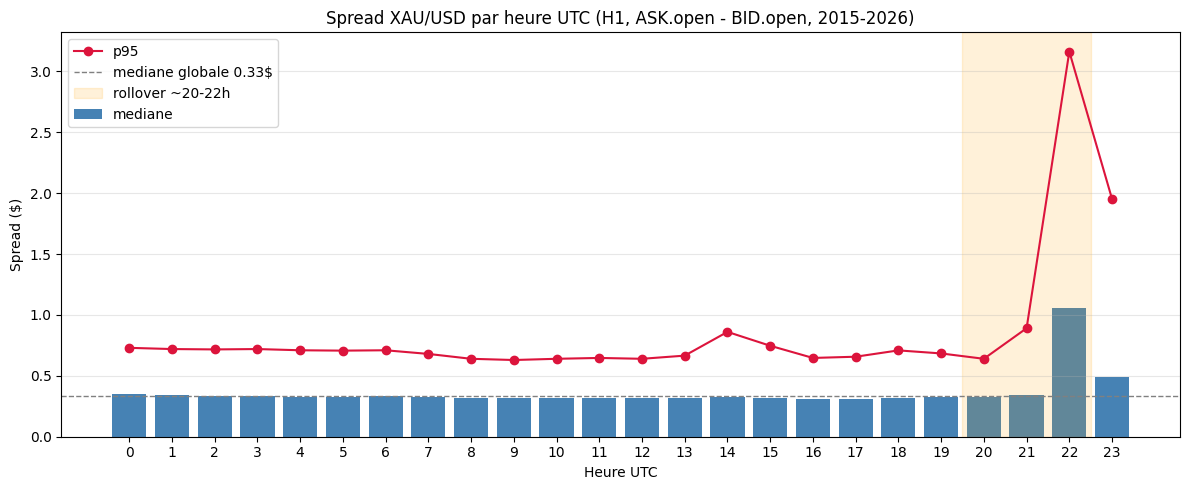

In [8]:
# ===== 02_ask_spread — CELL 8 : spread par heure UTC (H1) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

by_hour = pd.DataFrame({"spread": spread_h1.values}, index=spread_h1.index)
by_hour["hour"] = by_hour.index.hour

agg = by_hour.groupby("hour")["spread"].agg(
    mediane="median", moyenne="mean",
    p95=lambda s: s.quantile(0.95), n="size"
).round(3)

print("=== SPREAD H1 PAR HEURE UTC ===")
print(agg.to_string())

med_glob = float(spread_h1.median())
print(f"\nMediane globale : {med_glob:.3f} $")
worst = agg["mediane"].idxmax()
print(f"Heure la plus chere (mediane) : {worst}h UTC = {agg.loc[worst,'mediane']:.3f} $  "
      f"({agg.loc[worst,'mediane']/med_glob:.1f}x la mediane globale)")

# --- Graphe ---
fig, ax = plt.subplots(figsize=(12, 5))
x = agg.index
ax.bar(x, agg["mediane"], color="steelblue", label="mediane")
ax.plot(x, agg["p95"], color="crimson", marker="o", label="p95")
ax.axhline(med_glob, color="gray", ls="--", lw=1, label=f"mediane globale {med_glob:.2f}$")
ax.axvspan(19.5, 22.5, color="orange", alpha=0.15, label="rollover ~20-22h")
ax.set_xticks(range(24))
ax.set_xlabel("Heure UTC")
ax.set_ylabel("Spread ($)")
ax.set_title("Spread XAU/USD par heure UTC (H1, ASK.open - BID.open, 2015-2026)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ===== 02_ask_spread — CELL 9 : couche de spread M15 (controle de coherence) =====
bid_m15 = load_snapshot("XAUUSD_M15_BID_2015-01-01_2026-06-30_v1")
ask_m15 = load_snapshot("XAUUSD_M15_ASK_2015-01-01_2026-06-30_v1")

same_grid_m15 = bid_m15.index.equals(ask_m15.index)
print("Grille BID == ASK (M15) :", same_grid_m15)
if not same_grid_m15:
    common = bid_m15.index.intersection(ask_m15.index)
    print("  -> alignement sur intersection :", len(common), "barres")
    bid_m15, ask_m15 = bid_m15.loc[common], ask_m15.loc[common]

spread_m15 = (ask_m15["open"] - bid_m15["open"]).rename("spread")

print("\n=== SPREAD M15 (ASK.open - BID.open), 2015-2026 ===")
print("Barres          :", len(spread_m15))
print("Spread negatif  :", int((spread_m15 < 0).sum()), "barres")
print("Mediane         :", round(float(spread_m15.median()), 4), "$")
print("Moyenne         :", round(float(spread_m15.mean()), 4), "$")
print("p95 / p99       :", [round(float(spread_m15.quantile(q)), 3) for q in (0.95, 0.99)], "$")

# Pic horaire (par heure UTC, mediane)
tmp = pd.DataFrame({"spread": spread_m15.values}, index=spread_m15.index)
tmp["hour"] = tmp.index.hour
med_by_h = tmp.groupby("hour")["spread"].median().round(3)
worst_h = med_by_h.idxmax()
print(f"\nHeure la plus chere (mediane M15) : {worst_h}h UTC = {med_by_h[worst_h]:.3f} $")
print("Comparaison H1 : heure la plus chere = 22h UTC")
print("\nMediane M15 par heure (22h et voisines) :")
print(med_by_h.loc[[20, 21, 22, 23]].to_string())

Grille BID == ASK (M15) : True

=== SPREAD M15 (ASK.open - BID.open), 2015-2026 ===
Barres          : 271660
Spread negatif  : 0 barres
Mediane         : 0.328 $
Moyenne         : 0.3884 $
p95 / p99       : [0.73, 1.38] $

Heure la plus chere (mediane M15) : 22h UTC = 0.450 $
Comparaison H1 : heure la plus chere = 22h UTC

Mediane M15 par heure (22h et voisines) :
hour
20    0.340
21    0.360
22    0.450
23    0.391
